### Calculating the QM solution of the reaction between $OH^-$ and $CH_3Cl$ with MM water molecules

In [1]:
# import os
# import glob
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pyscf import gto, scf
# from pyscf.qmmm import mm_charge
# from pyscf.geomopt.geometric_solver import optimize
# from scipy.spatial.transform import Rotation
# import pickle

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.optimize import minimize
from scipy.spatial.transform import Rotation

from pyscf import gto, scf
from pyscf.qmmm import mm_charge

In [2]:
SCF_CONV_TOL = 1e-9
au_to_kJ_conversion = 2625.49962
bohr_to_A = 0.5291772109
A_to_bohr = 1.0 / bohr_to_A

In [3]:
def build_mm_water_sites(water_x_list):

    mm_coords = []
    mm_charges = []
    water_O_coords = []

    for water_x in water_x_list:

        O, H1, H2, M = water_from_variables(
            water_x
        )

        # Store oxygen positions separately
        # for the LJ calculation
        water_O_coords.append(O)

        # TIP4P-D electrostatic sites
        mm_coords.extend([
            H1,
            H2,
            M
        ])

        mm_charges.extend([
            0.58,
            0.58,
           -1.16
        ])

    return (
        np.array(mm_coords),
        np.array(mm_charges),
        np.array(water_O_coords)
    )
    
def water_from_variables(x):

    translation = np.asarray(x[:3])

    rotation = Rotation.from_rotvec(
        x[3:6]
    )

    O = translation + rotation.apply(
        water_O_local
    )

    H1 = translation + rotation.apply(
        water_H1_local
    )

    H2 = translation + rotation.apply(
        water_H2_local
    )

    M = translation + rotation.apply(
        water_M_local
    )

    return O, H1, H2, M
    
def lj_energy(r_A, sigma_A, epsilon_kJmol):
    """
    Lennard-Jones 12-6 energy.

    Parameters
    ----------
    r_A : float
        Distance in Angstrom
    sigma_A : float
        LJ sigma in Angstrom
    epsilon_kJmol : float
        LJ epsilon in kJ/mol

    Returns
    -------
    float
        LJ energy in kJ/mol
    """
    sr6 = (sigma_A / r_A)**6
    return 4.0 * epsilon_kJmol * (sr6**2 - sr6)

def qm_water_lj_energy_gradient(
    qm_coords_A,
    water_O_coords_A,
    qm_atom_types
):

    E_LJ = 0.0
    grad = np.zeros_like(qm_coords_A, dtype=float)

    for water_O in water_O_coords_A:

        for i, atom_type in enumerate(qm_atom_types):

            if atom_type not in qm_lj:
                continue

            sigma = qm_lj[atom_type]["sigma_A"]
            epsilon = qm_lj[atom_type]["epsilon_kJmol"]

            dr = qm_coords_A[i] - water_O

            r = np.linalg.norm(dr)

            sr6 = (sigma / r)**6

            # LJ energy
            E_i = 4.0 * epsilon * (sr6**2 - sr6)

            E_LJ += E_i

            # dE/dr
            dE_dr = (
                24.0 * epsilon / r
                * (sr6 - 2.0 * sr6**2)
            )

            # dE/dR
            grad[i] += dE_dr * dr / r

    return E_LJ, grad

def qm_water_lj_energy(
    qm_coords_A,
    water_O_coords_A,
    qm_atom_types
):

    E_LJ = 0.0

    for water_O in water_O_coords_A:

        for i, atom_type in enumerate(qm_atom_types):

            if atom_type not in qm_lj:
                continue

            sigma = qm_lj[atom_type]["sigma_A"]
            epsilon = qm_lj[atom_type]["epsilon_kJmol"]

            r = np.linalg.norm(
                qm_coords_A[i] - water_O
            )

            sr6 = (sigma / r)**6

            E_LJ += (
                4.0 * epsilon *
                (sr6**2 - sr6)
            )

    return E_LJ

def qmmm_lj_energy_gradient(coords_flat, water_x_list):
    """
    QM/MM electrostatic + QM-water LJ energy and gradient
    for multiple fixed TIP4P-D waters.
    """

    coords_A = np.asarray(coords_flat).reshape(-1, 3)

    mol = build_molecule(coords_A)

    # ------------------------------------------------------------
    # Build ALL MM waters
    # ------------------------------------------------------------

    mm_coords, mm_charges, water_O_coords = \
        build_mm_water_sites(water_x_list)

    # ------------------------------------------------------------
    # QM/MM electrostatics
    # ------------------------------------------------------------

    mf_qmmm = mm_charge(
        scf.RHF(mol),
        mm_coords,
        mm_charges,
        unit="Angstrom"
    )

    mf_qmmm.conv_tol = 1e-7
    mf_qmmm.max_cycle = 50
    mf_qmmm.diis_space = 12
    mf_qmmm.diis_start_cycle = 1

    E_qmmm_Ha = mf_qmmm.kernel()

    # ------------------------------------------------------------
    # QM/MM gradient
    # ------------------------------------------------------------

    grad_qmmm_Ha_Bohr = (
        mf_qmmm
        .nuc_grad_method()
        .kernel()
    )

    grad_qmmm = (
        grad_qmmm_Ha_Bohr
        * au_to_kJ_conversion
        / 1.889726125
    )

    # ------------------------------------------------------------
    # LJ interaction with ALL water oxygens
    # ------------------------------------------------------------

    E_LJ = 0.0
    grad_LJ = np.zeros_like(coords_A)

    for water_O in water_O_coords:

        E_one, grad_one = qm_water_lj_energy_gradient(
            coords_A,
            np.array([water_O]),
            qm_atom_types
        )

        E_LJ += E_one
        grad_LJ += grad_one

    # ------------------------------------------------------------
    # Total
    # ------------------------------------------------------------

    E_total = (
        E_qmmm_Ha * au_to_kJ_conversion
        + E_LJ
    )

    grad_total = (
        grad_qmmm
        + grad_LJ
    )

    return E_total, grad_total.ravel()
    
def move_oh_to_distance(coords, target_distance):

    coords = coords.copy()

    O = 0
    H_oh = 1
    C = 2

    carbon = coords[C]
    oxygen = coords[O]

    # Current direction from C toward O
    direction = oxygen - carbon
    direction /= np.linalg.norm(direction)

    # Preserve the O-H vector
    oh_vector = coords[H_oh] - coords[O]

    # Place O at the desired C-O distance
    new_oxygen = carbon + direction * target_distance

    # Move H together with O
    new_hydrogen = new_oxygen + oh_vector

    coords[O] = new_oxygen
    coords[H_oh] = new_hydrogen

    return coords

def build_molecule(coords):

    atom_string = ""

    for symbol, coord in zip(symbols, coords):

        x, y, z = coord

        atom_string += (
            f"{symbol} "
            f"{x:.10f} "
            f"{y:.10f} "
            f"{z:.10f}\n"
        )

    return gto.M(
        atom=atom_string,
        basis="6-31G",
        charge=-1,
        spin=0,
        unit="Angstrom"
    )
    
def write_constraint(distance):

    with open("constraints.txt", "w") as f:

        f.write("$set\n")
        f.write(
            f"distance 1 3 {distance:.8f}\n"
        )

def make_scf(mol):

    mf = scf.RHF(mol)
    return mf
    
def optimize_at_distance(mol, distance, maxsteps=15):

    # Create the constraint file
    write_constraint(distance)

    # Build RHF + implicit solvent
    mf = make_scf(mol)

    # Optimize geometry while keeping C-O fixed
    mol_opt = optimize(
        mf,
        constraints="constraints.txt",
        maxsteps=maxsteps
    )

    # Recalculate final energy using the optimized geometry
    mf_final = make_scf(mol_opt)
    energy = mf_final.kernel()

    # Return the optimized geometry and energy
    return mol_opt, energy, mf_final

def write_xyz(mol, filename, distance):

    coords = mol.atom_coords(
        unit="Angstrom"
    )

    with open(filename, "w") as f:

        f.write(f"{mol.natm}\n")

        f.write(
            f"C-O distance = {distance:.8f} Angstrom\n"
        )

        for symbol, coord in zip(symbols, coords):

            x, y, z = coord

            f.write(
                f"{symbol:2s} "
                f"{x:14.8f} "
                f"{y:14.8f} "
                f"{z:14.8f}\n"
            )



In [16]:
# Two fixed MM waters
water_x_list = [
    np.array([2.5,  2.0, 4.0, 0.0, 0.0, 0.0]),
    np.array([2.5, -1.0, 4.0, 2.0, 0.0, 0.0]),
    np.array([3.5, -3.0, 3.0, 0.0, 0.0, 0.0]),
]

initial_xyz = """
O   -5.000   0.000   0.000
H   -5.970   0.000   0.000

C    0.000   0.000   0.000
Cl   1.780   0.000   0.000

H   -0.630   0.630   0.630
H   -0.630  -0.630   0.630
H   -0.630   0.000  -0.890
"""

symbols = [
    "O",
    "H",
    "C",
    "Cl",
    "H",
    "H",
    "H"
]

mol = gto.M(
    atom=initial_xyz,
    basis="6-31G",
    charge=-1,
    spin=0,
    unit="Angstrom"
)

qm_atom_types = [
    "OH_O",
    "OH_H",
    "C",
    "Cl",
    "CH3_H",
    "CH3_H",
    "CH3_H"
]

# TIP4P-D water geometry
water_O_local = np.array([
    0.0, 0.0, 0.0
])

water_H1_local = np.array([
    0.9572, 0.0, 0.0
])

water_H2_local = np.array([
    -0.23998617,
     0.92662747,
     0.0
])

water_M_local = np.array([
    0.09462759,
    0.12225716,
    0.0
])


# TIP4P-D charges
water_charges = np.array([
    0.58,    # H1
    0.58,    # H2
   -1.16     # M site
])

qm_lj = {
    "OH_O": {
        "sigma_A": 3.400,
        "epsilon_kJmol": 0.2508914038369354
    },

    "OH_H": {
        "sigma_A": 1.443,
        "epsilon_kJmol": 0.18390926154006562
    },

    "C": {
        "sigma_A": 3.39967,
        "epsilon_kJmol": 0.457730
    },

    "Cl": {
        "sigma_A": 4.04468018036,
        "epsilon_kJmol": 0.6276
    },

    "CH3_H": {
        "sigma_A": 2.64953,
        "epsilon_kJmol": 0.0656888
    }
}

In [17]:
water_x = np.array([
    2.5,  # O x
    0.0,  # O y
    3.0,  # O z
    0.0,  # rotation x
    0.0,  # rotation y
    0.0   # rotation z
])

O, H1, H2, M = water_from_variables(water_x)

print("O :", O)
print("H1:", H1)
print("H2:", H2)
print("M :", M)

print()
print("O-H1 distance:",
      np.linalg.norm(H1 - O))

print("O-H2 distance:",
      np.linalg.norm(H2 - O))

print("H1-O-H2 angle:")

v1 = H1 - O
v2 = H2 - O

angle = np.degrees(
    np.arccos(
        np.dot(v1, v2)
        / np.linalg.norm(v1)
        / np.linalg.norm(v2)
    )
)

print(angle)

O : [2.5 0.  3. ]
H1: [3.4572 0.     3.    ]
H2: [2.26001383 0.92662747 3.        ]
M : [2.59462759 0.12225716 3.        ]

O-H1 distance: 0.9572000000000003
O-H2 distance: 0.9571999947502453
H1-O-H2 angle:
104.51993587385172


In [18]:
# Test the five TIP4P-D waters

mm_coords, mm_charges, water_O_coords = (
    build_mm_water_sites(water_x_list)
)

print("Number of MM charge sites:", len(mm_coords))
print("Number of water molecules:", len(water_O_coords))

print()
print("MM charge coordinates:")
print(mm_coords)

print()
print("MM charges:")
print(mm_charges)

print()
print("Water oxygen coordinates:")
print(water_O_coords)

Number of MM charge sites: 9
Number of water molecules: 3

MM charge coordinates:
[[ 3.4572      2.          4.        ]
 [ 2.26001383  2.92662747  4.        ]
 [ 2.59462759  2.12225716  4.        ]
 [ 3.4572     -1.          4.        ]
 [ 2.26001383 -1.38561309  4.84257997]
 [ 2.59462759 -1.05087693  4.11116812]
 [ 4.4572     -3.          3.        ]
 [ 3.26001383 -2.07337253  3.        ]
 [ 3.59462759 -2.87774284  3.        ]]

MM charges:
[ 0.58  0.58 -1.16  0.58  0.58 -1.16  0.58  0.58 -1.16]

Water oxygen coordinates:
[[ 2.5  2.   4. ]
 [ 2.5 -1.   4. ]
 [ 3.5 -3.   3. ]]


In [19]:
# Five-water QM/MM + LJ energy test

coords_A = mol.atom_coords(
    unit="Angstrom"
)

# ------------------------------------------------------------
# Build all five waters
# ------------------------------------------------------------

mm_coords, mm_charges, water_O_coords = (
    build_mm_water_sites(water_x_list)
)

# ------------------------------------------------------------
# Bare QM
# ------------------------------------------------------------

mf_qm = make_scf(mol)
E_qm_Ha = mf_qm.kernel()

# ------------------------------------------------------------
# QM/MM
# ------------------------------------------------------------

mf_qmmm = mm_charge(
    scf.RHF(mol),
    mm_coords,
    mm_charges,
    unit="Angstrom"
)

mf_qmmm.conv_tol = SCF_CONV_TOL

E_qmmm_Ha = mf_qmmm.kernel()

# ------------------------------------------------------------
# Electrostatic interaction
# ------------------------------------------------------------

E_electrostatic = (
    E_qmmm_Ha - E_qm_Ha
) * au_to_kJ_conversion

# ------------------------------------------------------------
# LJ interaction with all five waters
# ------------------------------------------------------------

E_LJ, grad_LJ = qm_water_lj_energy_gradient(
    coords_A,
    water_O_coords,
    qm_atom_types
)

# ------------------------------------------------------------
# Total interaction
# ------------------------------------------------------------

E_interaction = (
    E_electrostatic
    + E_LJ
)

print("=" * 60)
print("FIVE-WATER QM/MM + LJ TEST")
print("=" * 60)

print(
    f"Bare QM energy:             "
    f"{E_qm_Ha:.12f} Hartree"
)

print(
    f"QM/MM energy:               "
    f"{E_qmmm_Ha:.12f} Hartree"
)

print(
    f"Electrostatic interaction:  "
    f"{E_electrostatic:.6f} kJ/mol"
)

print(
    f"QM-water LJ:                "
    f"{E_LJ:.6f} kJ/mol"
)

print(
    f"Total interaction:          "
    f"{E_interaction:.6f} kJ/mol"
)

converged SCF energy = -574.308632235187
converged SCF energy = -574.301956996404
FIVE-WATER QM/MM + LJ TEST
Bare QM energy:             -574.308632235187 Hartree
QM/MM energy:               -574.301956996404 Hartree
Electrostatic interaction:  17.525837 kJ/mol
QM-water LJ:                -2.117245 kJ/mol
Total interaction:          15.408592 kJ/mol


In [20]:
# Five-water QM/MM + LJ gradient test

coords_A = mol.atom_coords(
    unit="Angstrom"
)

# Build all five waters
mm_coords, mm_charges, water_O_coords = (
    build_mm_water_sites(water_x_list)
)

# QM/MM SCF
mf_qmmm = mm_charge(
    scf.RHF(mol),
    mm_coords,
    mm_charges,
    unit="Angstrom"
)

mf_qmmm.conv_tol = SCF_CONV_TOL

E_qmmm_Ha = mf_qmmm.kernel()

# QM/MM gradient
grad_qmmm_Ha_Bohr = (
    mf_qmmm
    .nuc_grad_method()
    .kernel()
)

# Convert to kJ/mol/Angstrom
grad_qmmm = (
    grad_qmmm_Ha_Bohr
    * au_to_kJ_conversion
    / 1.889726125
)

# LJ gradient
E_LJ, grad_LJ = (
    qm_water_lj_energy_gradient(
        coords_A,
        water_O_coords,
        qm_atom_types
    )
)

# Total gradient
grad_total = grad_qmmm + grad_LJ

print("=" * 60)
print("FIVE-WATER GRADIENT TEST")
print("=" * 60)

print("Gradient (kJ/mol/Angstrom):")
print()

for i, (symbol, g) in enumerate(
    zip(symbols, grad_total)
):

    print(
        f"{i:2d} {symbol:2s} "
        f"{g[0]:12.6f} "
        f"{g[1]:12.6f} "
        f"{g[2]:12.6f}"
    )

print()
print(
    "Gradient norm:",
    np.linalg.norm(grad_total),
    "kJ/mol/Angstrom"
)

converged SCF energy = -574.301956996404
--------------- QMMMRHF gradients ---------------
         x                y                z
0 O    -0.0098765061    -0.0002907981    -0.0000231465
1 H     0.0078794393     0.0000401433    -0.0000204918
2 C     0.1145673958    -0.0000688345    -0.0271679676
3 Cl     0.0057675798    -0.0002108731    -0.0004626209
4 H    -0.0412666842    -0.0645485356     0.0068401842
5 H    -0.0414560181     0.0645939142     0.0071693195
6 H    -0.0359748628     0.0001379870     0.0144498697
----------------------------------------------
FIVE-WATER GRADIENT TEST
Gradient (kJ/mol/Angstrom):

 0 O    -13.727609    -0.403829    -0.034953
 1 H     10.947322     0.055774    -0.028476
 2 C    158.928235    -0.057112   -38.093550
 3 Cl     8.305152    -0.672971     1.088538
 4 H    -57.346162   -89.679504     9.491082
 5 H    -57.610893    89.744479     9.947599
 6 H    -49.984605     0.192113    20.072153

Gradient norm: 229.96279037596886 kJ/mol/Angstrom


In [21]:
# Simple five-water QM/MM + LJ optimization
# C and O are fixed; the other five QM atoms can move.

def optimize_five_water_system(
    mol,
    distance,
    water_x_list,
    maxiter=50
):

    # ------------------------------------------------------------
    # Starting geometry
    # ------------------------------------------------------------

    coords0 = mol.atom_coords(
        unit="Angstrom"
    ).copy()

    C_index = 2
    O_index = 0

    # Put C at the origin
    coords0 -= coords0[C_index]

    # Put O at the desired C-O distance
    coords0[O_index] = np.array([
        -distance,
        0.0,
        0.0
    ])

    coords0[C_index] = np.array([
        0.0,
        0.0,
        0.0
    ])

    # These atoms are allowed to move
    variable_atoms = [1, 3, 4, 5, 6]

    x0 = coords0[variable_atoms].ravel()

    # ------------------------------------------------------------
    # Build all five waters
    # ------------------------------------------------------------

    mm_coords, mm_charges, water_O_coords = (
        build_mm_water_sites(water_x_list)
    )

    # ------------------------------------------------------------
    # Energy + gradient
    # ------------------------------------------------------------

    def energy_and_gradient(x):

        coords = coords0.copy()

        coords[variable_atoms] = x.reshape(
            len(variable_atoms),
            3
        )

        # Build QM molecule
        mol_current = build_molecule(coords)

        # --------------------------------------------------------
        # QM/MM
        # --------------------------------------------------------

        mf_qmmm = mm_charge(
            scf.RHF(mol_current),
            mm_coords,
            mm_charges,
            unit="Angstrom"
        )

        mf_qmmm.conv_tol = 1e-7
        mf_qmmm.max_cycle = 50

        E_qmmm_Ha = mf_qmmm.kernel()

        # QM/MM gradient
        grad_qmmm_Ha_Bohr = (
            mf_qmmm
            .nuc_grad_method()
            .kernel()
        )

        grad_qmmm = (
            grad_qmmm_Ha_Bohr
            * au_to_kJ_conversion
            / 1.889726125
        )

        # --------------------------------------------------------
        # LJ
        # --------------------------------------------------------

        E_LJ, grad_LJ = (
            qm_water_lj_energy_gradient(
                coords,
                water_O_coords,
                qm_atom_types
            )
        )

        # --------------------------------------------------------
        # Total energy
        # --------------------------------------------------------

        E_total = (
            E_qmmm_Ha * au_to_kJ_conversion
            + E_LJ
        )

        # --------------------------------------------------------
        # Total gradient
        # --------------------------------------------------------

        grad_total = (
            grad_qmmm
            + grad_LJ
        )

        # Only return gradients for moving atoms
        grad_variable = (
            grad_total[variable_atoms]
        )

        return E_total, grad_variable.ravel()

    # ------------------------------------------------------------
    # Initial point
    # ------------------------------------------------------------

    E0, grad0 = energy_and_gradient(x0)

    print("=" * 60)
    print("FIVE-WATER QM/MM + LJ OPTIMIZATION")
    print("=" * 60)

    print(
        f"C-O distance: {distance:.3f} Å"
    )

    print(
        f"Initial energy: "
        f"{E0:.6f} kJ/mol"
    )

    print(
        f"Initial gradient: "
        f"{np.linalg.norm(grad0):.6f} kJ/mol/Å"
    )

    # ------------------------------------------------------------
    # Optimization
    # ------------------------------------------------------------

    result = minimize(
        fun=lambda x: energy_and_gradient(x)[0],
        x0=x0,
        jac=lambda x: energy_and_gradient(x)[1],
        method="BFGS",
        options={
            "maxiter": maxiter,
            "gtol": 1e-3,
            "disp": True
        }
    )

    # ------------------------------------------------------------
    # Final geometry
    # ------------------------------------------------------------

    coords_final = coords0.copy()

    coords_final[variable_atoms] = (
        result.x.reshape(
            len(variable_atoms),
            3
        )
    )

    mol_final = build_molecule(
        coords_final
    )

    # ------------------------------------------------------------
    # Final energy
    # ------------------------------------------------------------

    E_final, grad_final = (
        energy_and_gradient(result.x)
    )

    print()
    print("=" * 60)
    print("OPTIMIZATION RESULT")
    print("=" * 60)

    print(
        "Success:",
        result.success
    )

    print(
        "Message:",
        result.message
    )

    print(
        "Iterations:",
        result.nit
    )

    print(
        f"Initial energy: "
        f"{E0:.6f} kJ/mol"
    )

    print(
        f"Final energy:   "
        f"{E_final:.6f} kJ/mol"
    )

    print(
        f"Initial gradient:"
        f" {np.linalg.norm(grad0):.6f} kJ/mol/Å"
    )

    print(
        f"Final gradient:"
        f" {np.linalg.norm(grad_final):.6f} kJ/mol/Å"
    )

    print()
    print("Final geometry:")
    print(coords_final)

    return mol_final, E_final, result

In [22]:
E_total, grad = qmmm_lj_energy_gradient(
    mol.atom_coords(unit="Angstrom").ravel(),
    water_x_list
)

print("Total energy:", E_total, "kJ/mol")
print("Gradient norm:", np.linalg.norm(grad), "kJ/mol/A")

converged SCF energy = -574.301956996389
--------------- QMMMRHF gradients ---------------
         x                y                z
0 O    -0.0098762908    -0.0002908574    -0.0000232319
1 H     0.0078792098     0.0000402025    -0.0000204080
2 C     0.1145677863    -0.0000688414    -0.0271686335
3 Cl     0.0057673798    -0.0002108732    -0.0004621982
4 H    -0.0412667278    -0.0645483791     0.0068402496
5 H    -0.0414560550     0.0645937629     0.0071693841
6 H    -0.0359749652     0.0001379888     0.0144499852
----------------------------------------------
Total energy: -1507831.687103943 kJ/mol
Gradient norm: 229.96319217829662 kJ/mol/A


In [23]:
print("Number of waters:", len(water_x_list))

mm_coords, mm_charges, water_O_coords = \
    build_mm_water_sites(water_x_list)

print("\nWater oxygen positions:")
for i, O in enumerate(water_O_coords):
    print(i, O)

print("\nNumber of MM charge sites:", len(mm_coords))
print("Number of MM charges:", len(mm_charges))
print("Total MM charge:", np.sum(mm_charges))

Number of waters: 3

Water oxygen positions:
0 [2.5 2.  4. ]
1 [ 2.5 -1.   4. ]
2 [ 3.5 -3.   3. ]

Number of MM charge sites: 9
Number of MM charges: 9
Total MM charge: 0.0


In [24]:
E_total_1, grad_1 = qmmm_lj_energy_gradient(
    mol.atom_coords(unit="Angstrom").ravel(),
    [water_x_list[0]]
)

E_total_5, grad_5 = qmmm_lj_energy_gradient(
    mol.atom_coords(unit="Angstrom").ravel(),
    water_x_list
)

print("One-water energy :", E_total_1)
print("Five-water energy:", E_total_5)

print()

print(
    "One-water gradient norm :",
    np.linalg.norm(grad_1)
)

print(
    "Five-water gradient norm:",
    np.linalg.norm(grad_5)
)

converged SCF energy = -574.30589967509
--------------- QMMMRHF gradients ---------------
         x                y                z
0 O    -0.0099985604    -0.0000927070    -0.0001488809
1 H     0.0075979713     0.0000153387    -0.0000107662
2 C     0.1144474244    -0.0000984494    -0.0269312952
3 Cl     0.0058023013     0.0000974466    -0.0011234085
4 H    -0.0410953621    -0.0647778602     0.0072060001
5 H    -0.0410049251     0.0647582756     0.0072204600
6 H    -0.0358186378     0.0000611524     0.0142414943
----------------------------------------------
converged SCF energy = -574.301956996388
--------------- QMMMRHF gradients ---------------
         x                y                z
0 O    -0.0098762908    -0.0002908574    -0.0000232319
1 H     0.0078792098     0.0000402025    -0.0000204080
2 C     0.1145677863    -0.0000688414    -0.0271686335
3 Cl     0.0057673798    -0.0002108732    -0.0004621982
4 H    -0.0412667278    -0.0645483791     0.0068402496
5 H    -0.0414560550

In [29]:
def water_water_energy_gradient(water_x_list):
    """
    TIP4P-D water-water interaction energy and gradient.

    Each water is represented by 6 variables:
        x, y, z, rot_x, rot_y, rot_z

    Includes:
        - electrostatic interaction between H/H/M charge sites
        - O-O Lennard-Jones interaction

    Returns
    -------
    E_total : float
        Water-water interaction energy in kJ/mol

    grad : ndarray
        Gradient with respect to all water variables.
        Shape = (6 * number_of_waters,)
    """

    n_waters = len(water_x_list)

    # ------------------------------------------------------------
    # Build all water coordinates
    # ------------------------------------------------------------

    waters = []

    for water_x in water_x_list:

        O, H1, H2, M = water_from_variables(water_x)

        waters.append({
            "O": O,
            "H1": H1,
            "H2": H2,
            "M": M
        })

    # ------------------------------------------------------------
    # Constants
    # ------------------------------------------------------------

    # Coulomb conversion:
    # kcal/mol -> kJ/mol
    # 1/(4*pi*epsilon0) in kJ mol^-1 A e^-2
    coulomb_constant = 138.935456

    # TIP4P-D O-O LJ parameters
    #
    # These should be the TIP4P-D values you intend to use.
    #
    # TIP4P-D:
    # sigma = 3.1589 A
    # epsilon = 0.1852 kcal/mol
    #
    # Convert epsilon to kJ/mol.

    sigma_OO = 3.1589
    epsilon_OO = 0.1852 * 4.184

    E_total = 0.0

    # ------------------------------------------------------------
    # Pairwise water-water interactions
    # ------------------------------------------------------------

    for i in range(n_waters):

        for j in range(i + 1, n_waters):

            wi = waters[i]
            wj = waters[j]

            # ----------------------------------------------------
            # Electrostatics
            # ----------------------------------------------------

            sites_i = [
                (wi["H1"],  0.58),
                (wi["H2"],  0.58),
                (wi["M"],  -1.16)
            ]

            sites_j = [
                (wj["H1"],  0.58),
                (wj["H2"],  0.58),
                (wj["M"],  -1.16)
            ]

            for ri, qi in sites_i:

                for rj, qj in sites_j:

                    r_vec = ri - rj
                    r = np.linalg.norm(r_vec)

                    E_total += (
                        coulomb_constant
                        * qi * qj
                        / r
                    )

            # ----------------------------------------------------
            # O-O Lennard-Jones
            # ----------------------------------------------------

            r_vec = wi["O"] - wj["O"]
            r = np.linalg.norm(r_vec)

            sr6 = (sigma_OO / r)**6

            E_total += (
                4.0 * epsilon_OO
                * (sr6**2 - sr6)
            )

    # ------------------------------------------------------------
    # Numerical gradient
    #
    # For now this is intentionally numerical.
    # It lets us verify the energy implementation before
    # deriving the rotational forces analytically.
    # ------------------------------------------------------------

    gradient = np.zeros(
        6 * n_waters
    )

    dx = 1.0e-5

    x_all = np.concatenate(
        water_x_list
    )

    for k in range(len(x_all)):

        x_plus = x_all.copy()
        x_minus = x_all.copy()

        x_plus[k] += dx
        x_minus[k] -= dx

        water_plus = [
            x_plus[6*i:6*i+6].copy()
            for i in range(n_waters)
        ]

        water_minus = [
            x_minus[6*i:6*i+6].copy()
            for i in range(n_waters)
        ]

        E_plus = water_water_energy(
            water_plus
        )

        E_minus = water_water_energy(
            water_minus
        )

        gradient[k] = (
            E_plus - E_minus
        ) / (2.0 * dx)

    return E_total, gradient


def water_water_energy(water_x_list):
    """
    TIP4P-D water-water interaction energy only.
    """

    n_waters = len(water_x_list)

    waters = []

    for water_x in water_x_list:

        O, H1, H2, M = water_from_variables(
            water_x
        )

        waters.append({
            "O": O,
            "H1": H1,
            "H2": H2,
            "M": M
        })

    coulomb_constant = 138.935456

    sigma_OO = 3.1589
    epsilon_OO = 0.1852 * 4.184

    E_total = 0.0

    for i in range(n_waters):

        for j in range(i + 1, n_waters):

            wi = waters[i]
            wj = waters[j]

            sites_i = [
                (wi["H1"],  0.58),
                (wi["H2"],  0.58),
                (wi["M"],  -1.16)
            ]

            sites_j = [
                (wj["H1"],  0.58),
                (wj["H2"],  0.58),
                (wj["M"],  -1.16)
            ]

            # Electrostatics

            for ri, qi in sites_i:

                for rj, qj in sites_j:

                    r = np.linalg.norm(
                        ri - rj
                    )

                    E_total += (
                        coulomb_constant
                        * qi * qj
                        / r
                    )

            # O-O LJ

            r = np.linalg.norm(
                wi["O"] - wj["O"]
            )

            sr6 = (
                sigma_OO / r
            )**6

            E_total += (
                4.0 * epsilon_OO
                * (sr6**2 - sr6)
            )

    return E_total

def total_qmmm_energy_gradient(
    coords_flat,
    water_x_list
):
    """
    Total QM/MM + QM-water LJ + water-water energy.

    QM coordinates are variables.
    Water coordinates are fixed in this function.

    Returns
    -------
    E_total : float
        Total energy in kJ/mol

    grad_total : ndarray
        Gradient with respect to QM coordinates,
        in kJ/mol/Angstrom.
    """

    coords_A = np.asarray(
        coords_flat
    ).reshape(-1, 3)

    # ------------------------------------------------------------
    # Build MM waters
    # ------------------------------------------------------------

    (
        mm_coords,
        mm_charges,
        water_O_coords
    ) = build_mm_water_sites(
        water_x_list
    )

    # ------------------------------------------------------------
    # QM molecule
    # ------------------------------------------------------------

    mol_current = build_molecule(
        coords_A
    )

    # ------------------------------------------------------------
    # QM/MM electrostatics
    # ------------------------------------------------------------

    mf_qmmm = mm_charge(
        scf.RHF(mol_current),
        mm_coords,
        mm_charges,
        unit="Angstrom"
    )

    mf_qmmm.conv_tol = 1e-7
    mf_qmmm.max_cycle = 50
    mf_qmmm.diis_space = 12
    mf_qmmm.diis_start_cycle = 1

    E_qmmm_Ha = mf_qmmm.kernel()

    # ------------------------------------------------------------
    # QM/MM gradient
    # ------------------------------------------------------------

    grad_qmmm_Ha_Bohr = (
        mf_qmmm
        .nuc_grad_method()
        .kernel()
    )

    grad_qmmm = (
        grad_qmmm_Ha_Bohr
        * au_to_kJ_conversion
        / 1.889726125
    )

    # ------------------------------------------------------------
    # QM-water LJ
    # ------------------------------------------------------------

    E_LJ, grad_LJ = (
        qm_water_lj_energy_gradient(
            coords_A,
            water_O_coords,
            qm_atom_types
        )
    )

    # ------------------------------------------------------------
    # Water-water
    #
    # This contributes energy but NOT to the QM gradient.
    # ------------------------------------------------------------

    E_WW, grad_WW = (
        water_water_energy_gradient(
            water_x_list
        )
    )

    # ------------------------------------------------------------
    # Total energy
    # ------------------------------------------------------------

    E_total = (
        E_qmmm_Ha * au_to_kJ_conversion
        + E_LJ
        + E_WW
    )

    # ------------------------------------------------------------
    # Total QM gradient
    # ------------------------------------------------------------

    grad_total = (
        grad_qmmm
        + grad_LJ
    )

    return (
        E_total,
        grad_total.ravel()
    )

In [26]:
E_ww, grad_ww = water_water_energy_gradient(
    water_x_list
)

print("=" * 60)
print("WATER-WATER TIP4P-D TEST")
print("=" * 60)

print(
    f"Water-water energy: "
    f"{E_ww:.8f} kJ/mol"
)

print(
    f"Gradient norm: "
    f"{np.linalg.norm(grad_ww):.8f} kJ/mol/(variable)"
)

print()
print("Gradient:")
print(
    grad_ww.reshape(
        len(water_x_list),
        6
    )
)

WATER-WATER TIP4P-D TEST
Water-water energy: 52.53994267 kJ/mol
Gradient norm: 390.37826409 kJ/mol/(variable)

Gradient:
[[-1.93586186e-01 -1.60195922e+01 -1.68950603e-01  1.16923123e-01
  -1.26086552e-01 -4.80397195e-01]
 [ 1.10302757e+02 -2.16836734e+02 -1.14983490e+02 -1.10047715e+00
   3.72306729e-01 -6.23158294e+00]
 [-1.10109171e+02  2.32856326e+02  1.15152441e+02 -1.06103877e+00
  -1.30128243e+00 -9.10939803e+00]]


In [27]:
print("=" * 60)
print("WATER-WATER O-O DISTANCES")
print("=" * 60)

for i in range(len(water_x_list)):

    Oi, _, _, _ = water_from_variables(
        water_x_list[i]
    )

    for j in range(i + 1, len(water_x_list)):

        Oj, _, _, _ = water_from_variables(
            water_x_list[j]
        )

        r = np.linalg.norm(Oi - Oj)

        print(
            f"Water {i+1} - Water {j+1}: "
            f"{r:.3f} Å"
        )
        

WATER-WATER O-O DISTANCES
Water 1 - Water 2: 3.000 Å
Water 1 - Water 3: 5.196 Å
Water 2 - Water 3: 2.449 Å


In [28]:
E_ww, grad_ww = water_water_energy_gradient(
    water_x_list
)

print("=" * 60)
print("WATER-WATER TIP4P-D TEST")
print("=" * 60)

print(
    f"Water-water energy: "
    f"{E_ww:.8f} kJ/mol"
)

print(
    f"Gradient norm: "
    f"{np.linalg.norm(grad_ww):.8f}"
)

print()
print("Gradient:")
print(
    grad_ww.reshape(
        len(water_x_list),
        6
    )
)

WATER-WATER TIP4P-D TEST
Water-water energy: 52.53994267 kJ/mol
Gradient norm: 390.37826409

Gradient:
[[-1.93586186e-01 -1.60195922e+01 -1.68950603e-01  1.16923123e-01
  -1.26086552e-01 -4.80397195e-01]
 [ 1.10302757e+02 -2.16836734e+02 -1.14983490e+02 -1.10047715e+00
   3.72306729e-01 -6.23158294e+00]
 [-1.10109171e+02  2.32856326e+02  1.15152441e+02 -1.06103877e+00
  -1.30128243e+00 -9.10939803e+00]]


In [30]:
coords_A = mol.atom_coords(
    unit="Angstrom"
)

E_total, grad_total = (
    total_qmmm_energy_gradient(
        coords_A.ravel(),
        water_x_list
    )
)

print("=" * 60)
print("TOTAL QM/MM ENERGY TEST")
print("=" * 60)

print(
    f"Total energy: "
    f"{E_total:.8f} kJ/mol"
)

print(
    f"QM gradient norm: "
    f"{np.linalg.norm(grad_total):.8f} "
    f"kJ/mol/Angstrom"
)

converged SCF energy = -574.301956996388
--------------- QMMMRHF gradients ---------------
         x                y                z
0 O    -0.0098762908    -0.0002908574    -0.0000232319
1 H     0.0078792098     0.0000402025    -0.0000204080
2 C     0.1145677863    -0.0000688414    -0.0271686335
3 Cl     0.0057673798    -0.0002108732    -0.0004621982
4 H    -0.0412667278    -0.0645483791     0.0068402496
5 H    -0.0414560550     0.0645937629     0.0071693841
6 H    -0.0359749652     0.0001379888     0.0144499852
----------------------------------------------
TOTAL QM/MM ENERGY TEST
Total energy: -1507779.14716127 kJ/mol
QM gradient norm: 229.96319218 kJ/mol/Angstrom


In [31]:
def total_qmmm_interaction_energy_gradient(
    coords_flat,
    water_x_list
):
    """
    QM/MM interaction energy including:

        QM/MM electrostatics
        QM-water Lennard-Jones
        water-water TIP4P-D interaction

    The absolute QM energy is subtracted so that the returned
    energy represents the interaction energy relative to the
    isolated QM system at the same geometry.

    Gradient is with respect to QM coordinates only.

    Energy:
        kJ/mol

    Gradient:
        kJ/mol/Angstrom
    """

    coords_A = np.asarray(
        coords_flat
    ).reshape(-1, 3)

    # ------------------------------------------------------------
    # Build MM waters
    # ------------------------------------------------------------

    (
        mm_coords,
        mm_charges,
        water_O_coords
    ) = build_mm_water_sites(
        water_x_list
    )

    # ------------------------------------------------------------
    # Build QM molecule
    # ------------------------------------------------------------

    mol_current = build_molecule(
        coords_A
    )

    # ------------------------------------------------------------
    # Bare QM
    # ------------------------------------------------------------

    mf_qm = scf.RHF(
        mol_current
    )

    mf_qm.conv_tol = 1e-7

    E_qm_Ha = mf_qm.kernel()

    # ------------------------------------------------------------
    # QM/MM electrostatic embedding
    # ------------------------------------------------------------

    mf_qmmm = mm_charge(
        scf.RHF(mol_current),
        mm_coords,
        mm_charges,
        unit="Angstrom"
    )

    mf_qmmm.conv_tol = 1e-7
    mf_qmmm.max_cycle = 50
    mf_qmmm.diis_space = 12
    mf_qmmm.diis_start_cycle = 1

    E_qmmm_Ha = mf_qmmm.kernel()

    # ------------------------------------------------------------
    # QM/MM gradient
    # ------------------------------------------------------------

    grad_qmmm_Ha_Bohr = (
        mf_qmmm
        .nuc_grad_method()
        .kernel()
    )

    grad_qmmm = (
        grad_qmmm_Ha_Bohr
        * au_to_kJ_conversion
        / 1.889726125
    )

    # ------------------------------------------------------------
    # QM-water LJ
    # ------------------------------------------------------------

    E_LJ, grad_LJ = (
        qm_water_lj_energy_gradient(
            coords_A,
            water_O_coords,
            qm_atom_types
        )
    )

    # ------------------------------------------------------------
    # Water-water interaction
    # ------------------------------------------------------------

    E_WW, grad_WW = (
        water_water_energy_gradient(
            water_x_list
        )
    )

    # ------------------------------------------------------------
    # Electrostatic interaction energy
    # ------------------------------------------------------------

    E_electrostatic = (
        E_qmmm_Ha - E_qm_Ha
    ) * au_to_kJ_conversion

    # ------------------------------------------------------------
    # Total interaction energy
    # ------------------------------------------------------------

    E_total = (
        E_electrostatic
        + E_LJ
        + E_WW
    )

    # ------------------------------------------------------------
    # QM gradient
    #
    # NOTE:
    # The water-water term has no derivative with respect
    # to QM coordinates.
    # ------------------------------------------------------------

    grad_total = (
        grad_qmmm
        + grad_LJ
    )

    return (
        E_total,
        grad_total.ravel()
    )

In [32]:
coords_A = mol.atom_coords(
    unit="Angstrom"
)

E_total, grad_total = (
    total_qmmm_interaction_energy_gradient(
        coords_A.ravel(),
        water_x_list
    )
)

print("=" * 60)
print("TOTAL QM/MM INTERACTION ENERGY TEST")
print("=" * 60)

print(
    f"Total interaction energy: "
    f"{E_total:.8f} kJ/mol"
)

print(
    f"QM gradient norm: "
    f"{np.linalg.norm(grad_total):.8f} "
    f"kJ/mol/Angstrom"
)

converged SCF energy = -574.308632235171
converged SCF energy = -574.301956996388
--------------- QMMMRHF gradients ---------------
         x                y                z
0 O    -0.0098762908    -0.0002908574    -0.0000232319
1 H     0.0078792098     0.0000402025    -0.0000204080
2 C     0.1145677863    -0.0000688414    -0.0271686335
3 Cl     0.0057673798    -0.0002108732    -0.0004621982
4 H    -0.0412667278    -0.0645483791     0.0068402496
5 H    -0.0414560550     0.0645937629     0.0071693841
6 H    -0.0359749652     0.0001379888     0.0144499852
----------------------------------------------
TOTAL QM/MM INTERACTION ENERGY TEST
Total interaction energy: 67.94853489 kJ/mol
QM gradient norm: 229.96319218 kJ/mol/Angstrom


In [33]:
def reaction_energy_at_distance(
    distance,
    starting_coords,
    water_x_list
):
    """
    Calculate the QM/MM interaction energy at a specified
    C-O distance.

    The QM geometry is generated by moving OH relative
    to CH3Cl while preserving the O-H vector.

    MM waters remain fixed.

    Returns
    -------
    result : dict
        Contains QM energy, QM/MM energy, electrostatic
        interaction, LJ interaction, water-water energy,
        and total interaction energy.
    """

    # ------------------------------------------------------------
    # Set the C-O distance
    # ------------------------------------------------------------

    coords = move_oh_to_distance(
        starting_coords,
        distance
    )

    # ------------------------------------------------------------
    # Build QM molecule
    # ------------------------------------------------------------

    mol_current = build_molecule(
        coords
    )

    # ------------------------------------------------------------
    # MM water sites
    # ------------------------------------------------------------

    (
        mm_coords,
        mm_charges,
        water_O_coords
    ) = build_mm_water_sites(
        water_x_list
    )

    # ------------------------------------------------------------
    # Bare QM
    # ------------------------------------------------------------

    mf_qm = scf.RHF(
        mol_current
    )

    mf_qm.conv_tol = SCF_CONV_TOL

    E_qm_Ha = mf_qm.kernel()

    # ------------------------------------------------------------
    # QM/MM
    # ------------------------------------------------------------

    mf_qmmm = mm_charge(
        scf.RHF(mol_current),
        mm_coords,
        mm_charges,
        unit="Angstrom"
    )

    mf_qmmm.conv_tol = SCF_CONV_TOL
    mf_qmmm.max_cycle = 50
    mf_qmmm.diis_space = 12
    mf_qmmm.diis_start_cycle = 1

    E_qmmm_Ha = mf_qmmm.kernel()

    # ------------------------------------------------------------
    # Electrostatic interaction
    # ------------------------------------------------------------

    E_electrostatic = (
        E_qmmm_Ha - E_qm_Ha
    ) * au_to_kJ_conversion

    # ------------------------------------------------------------
    # QM-water LJ
    # ------------------------------------------------------------

    E_LJ = qm_water_lj_energy(
        coords,
        water_O_coords,
        qm_atom_types
    )

    # ------------------------------------------------------------
    # Water-water interaction
    # ------------------------------------------------------------

    E_WW = water_water_energy(
        water_x_list
    )

    # ------------------------------------------------------------
    # Total interaction energy
    # ------------------------------------------------------------

    E_total = (
        E_electrostatic
        + E_LJ
        + E_WW
    )

    return {
        "distance": distance,
        "E_qm_Ha": E_qm_Ha,
        "E_qmmm_Ha": E_qmmm_Ha,
        "E_electrostatic": E_electrostatic,
        "E_LJ": E_LJ,
        "E_WW": E_WW,
        "E_total": E_total
    }

In [34]:
starting_coords = mol.atom_coords(
    unit="Angstrom"
).copy()

distances = np.arange(
    2.0,
    5.01,
    0.25
)

scan_results = []

for distance in distances:

    print(
        f"\nCalculating C-O = "
        f"{distance:.2f} Å"
    )

    result = reaction_energy_at_distance(
        distance,
        starting_coords,
        water_x_list
    )

    scan_results.append(
        result
    )

    print(
        f"Electrostatic = "
        f"{result['E_electrostatic']:.6f} kJ/mol"
    )

    print(
        f"QM-water LJ   = "
        f"{result['E_LJ']:.6f} kJ/mol"
    )

    print(
        f"Water-water   = "
        f"{result['E_WW']:.6f} kJ/mol"
    )

    print(
        f"Total         = "
        f"{result['E_total']:.6f} kJ/mol"
    )


Calculating C-O = 2.00 Å
converged SCF energy = -574.29535038469
converged SCF energy = -574.282236730946
Electrostatic = 34.429893 kJ/mol
QM-water LJ   = -2.173773 kJ/mol
Water-water   = 52.539943 kJ/mol
Total         = 84.796063 kJ/mol

Calculating C-O = 2.25 Å
converged SCF energy = -574.334085625485
converged SCF energy = -574.321731963676
Electrostatic = 32.434534 kJ/mol
QM-water LJ   = -2.163453 kJ/mol
Water-water   = 52.539943 kJ/mol
Total         = 82.811024 kJ/mol

Calculating C-O = 2.50 Å
converged SCF energy = -574.344086084353
converged SCF energy = -574.332442092097
Electrostatic = 30.571297 kJ/mol
QM-water LJ   = -2.154772 kJ/mol
Water-water   = 52.539943 kJ/mol
Total         = 80.956468 kJ/mol

Calculating C-O = 2.75 Å
converged SCF energy = -574.342678461267
converged SCF energy = -574.331703709174
Electrostatic = 28.814207 kJ/mol
QM-water LJ   = -2.147483 kJ/mol
Water-water   = 52.539943 kJ/mol
Total         = 79.206667 kJ/mol

Calculating C-O = 3.00 Å
converged SCF e

In [35]:
distances = np.array([
    r["distance"]
    for r in scan_results
])

E_total = np.array([
    r["E_total"]
    for r in scan_results
])

E_electrostatic = np.array([
    r["E_electrostatic"]
    for r in scan_results
])

E_LJ = np.array([
    r["E_LJ"]
    for r in scan_results
])

E_WW = np.array([
    r["E_WW"]
    for r in scan_results
])

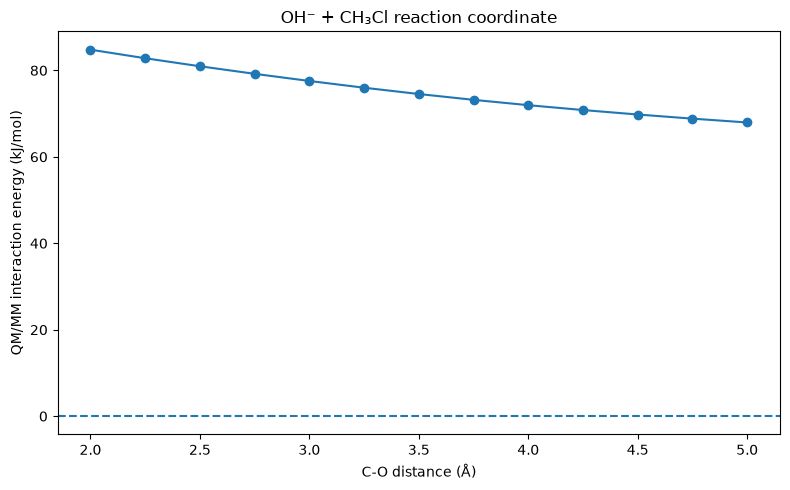

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    distances,
    E_total,
    marker="o"
)

plt.axhline(
    0.0,
    linestyle="--"
)

plt.xlabel(
    "C-O distance (Å)"
)

plt.ylabel(
    "QM/MM interaction energy (kJ/mol)"
)

plt.title(
    "OH⁻ + CH₃Cl reaction coordinate"
)

plt.tight_layout()

plt.show()

In [37]:
# ------------------------------------------------------------
# Five MM TIP4P-D waters
# ------------------------------------------------------------

mm_coords, mm_charges, water_O_coords = (
    build_mm_water_sites(water_x_list)
)

print("Number of MM sites:", len(mm_coords))
print("Total MM charge:", np.sum(mm_charges))

# ------------------------------------------------------------
# Bare QM
# ------------------------------------------------------------

mf_qm = scf.RHF(mol)
mf_qm.conv_tol = SCF_CONV_TOL

E_qm = mf_qm.kernel()

# ------------------------------------------------------------
# QM + five MM waters
# ------------------------------------------------------------

mf_qmmm = mm_charge(
    scf.RHF(mol),
    mm_coords,
    mm_charges,
    unit="Angstrom"
)

mf_qmmm.conv_tol = SCF_CONV_TOL

E_qmmm = mf_qmmm.kernel()

# ------------------------------------------------------------
# Interaction energy
# ------------------------------------------------------------

E_interaction = (
    E_qmmm - E_qm
) * au_to_kJ_conversion

print()
print("=" * 60)
print("QM + FIVE MM WATER TEST")
print("=" * 60)

print(
    f"QM energy:             {E_qm:.12f} Ha"
)

print(
    f"QM/MM energy:          {E_qmmm:.12f} Ha"
)

print(
    f"Electrostatic effect:  "
    f"{E_interaction:.6f} kJ/mol"
)

Number of MM sites: 9
Total MM charge: 0.0
converged SCF energy = -574.308632235187
converged SCF energy = -574.301956996404

QM + FIVE MM WATER TEST
QM energy:             -574.308632235187 Ha
QM/MM energy:          -574.301956996404 Ha
Electrostatic effect:  17.525837 kJ/mol
